# Pan-cancer expression patterns and BRCA subclustering
**Zirui Chen · NTU Biomedical Data Science coursework portfolio**

Do gene-expression profiles recover broad tumor-type structure, and what further
grouping is visible within breast cancer? This analysis uses PCA, variance filtering
and hierarchical clustering on a course-provided TCGA pan-cancer subset.

The dataset contains **20,531 genes and 801 samples** from BRCA, COAD, KIRC, LUAD and
PRAD. Source: *Homework Assignment 4*, slide 1. Input details are in [data/README.md](../data/README.md).

This notebook is an editorial reorganization of the original homework. Methods,
parameters and saved results are retained; no analysis was rerun for this edition.
Code has been divided into shorter cells, so old execution numbers were cleared.
Original results are presented separately below the corresponding sections.


In [ ]:
from pathlib import Path
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Open from the repository root or its notebooks/ directory.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "raw"
RESULT_DIR = ROOT / "results" / "pan_cancer" / "rerun"


## 1. Load expression and tumor labels

Expression has genes in rows and sample IDs in columns. The supplied label order matches the expression columns. The original loading logic is retained.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy import stats

print("Loading data...")

data = pd.read_csv(DATA_DIR / "HW4data.csv", index_col=0)
labels = pd.read_csv(DATA_DIR / "HW4labels.csv", index_col=0)

print(f"data shape: {data.shape}")
print(f"label shape: {labels.shape}")
print(f"number of sample: {data.shape[1]}")
print(f"number of gene: {data.shape[0]}")
print(f"label distribution :\n{labels['Class'].value_counts()}")


## 2. Explore tumor-type structure with PCA

Genes are standardized across samples before PCA. The first three PCs explained **27.10%** of variance in the saved run. Labels color the projections; they are not used to fit PCA.


In [ ]:
print("\n2. Perform PCA analysis...")

X = data.T.values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Class'] = labels['Class'].values

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative Explained Variance: {np.cumsum(pca.explained_variance_ratio_)}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = {'BRCA': 'red', 'COAD': 'blue', 'KIRC': 'green', 'LUAD': 'orange', 'PRAD': 'purple'}
for tumor_type, color in colors.items():
    mask = pca_df['Class'] == tumor_type
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], 
               c=color, label=tumor_type, alpha=0.6, s=30)
plt.xlabel('PC1 (Explained variance: {:.1f}%))'.format(pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (Explained variance: {:.1f}%))'.format(pca.explained_variance_ratio_[1]*100))
plt.title('PC1 vs PC2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for tumor_type, color in colors.items():
    mask = pca_df['Class'] == tumor_type
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC3'], 
               c=color, label=tumor_type, alpha=0.6, s=30)
plt.xlabel('PC1 (Explained variance: {:.1f}%))'.format(pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC3 (Explained variance: {:.1f}%))'.format(pca.explained_variance_ratio_[2]*100))
plt.title('PC1 vs PC3')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')  

for tumor_type, color in colors.items():
    mask = pca_df['Class'] == tumor_type
    ax.scatter(pca_df.loc[mask, 'PC1'], 
               pca_df.loc[mask, 'PC2'],  
               pca_df.loc[mask, 'PC3'],  
               c=color, label=tumor_type, alpha=0.6, s=30)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')  
ax.set_title('3D PCA Plot')
ax.legend()
plt.show()


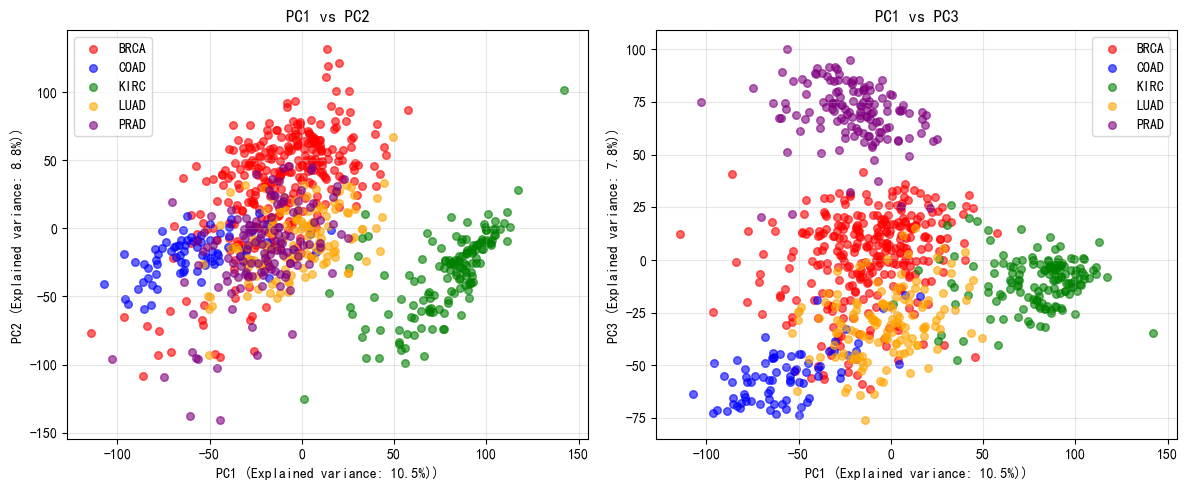

*Figure retained from the original homework run; not regenerated.*


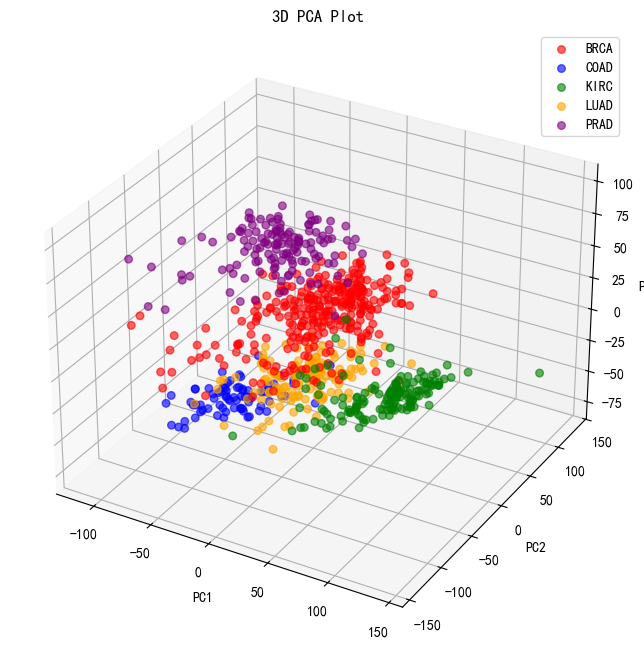

*Figure retained from the original homework run; not regenerated.*


## 3. Select variable genes

The original endpoint-distance elbow heuristic retained **1,419 genes**. The cumulative variance curve summarizes marginal gene variances, not PCA explained variance.


In [ ]:
print("\n3. Gene Screening - Based on Variance...")

gene_variances = data.var(axis=1)
gene_variances_sorted = np.sort(gene_variances)[::-1]

def find_elbow_by_distance(variances_sorted):
    """Using the Distance Method to Find the Elbow Point"""
    n = len(variances_sorted)
    x = np.arange(1, n + 1)
    y = variances_sorted

    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    distances = []
    for i in range(n):
        p = np.array([x[i], y[i]])

        d = np.abs(((p2-p1)[0] * (p1-p)[1] - (p2-p1)[1] * (p1-p)[0])) / np.linalg.norm(p2-p1)
        distances.append(d)
    
    elbow_idx = np.argmax(distances)
    return elbow_idx

elbow_idx = find_elbow_by_distance(gene_variances_sorted)
N = elbow_idx + 1

print(f"Distance-based method-determined elbow point location: The {N}th gene")
print(f"Variance value at the elbow point: {gene_variances_sorted[elbow_idx]}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(gene_variances_sorted)+1), gene_variances_sorted, linewidth=2, color='blue')
plt.axvline(x=N, color='red', linestyle='--', linewidth=2, 
           label=f'Elbow point (N={N})')
plt.xlabel('Gene Ranking')
plt.ylabel('Variance')
plt.title('Gene Variance Ranking Plot (Elbow Point Identification via Distance Method)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_var = np.cumsum(gene_variances_sorted) / np.sum(gene_variances_sorted)
plt.plot(range(1, len(gene_variances_sorted)+1), cumulative_var, linewidth=2, color='green')
plt.axvline(x=N, color='red', linestyle='--', linewidth=2, 
           label=f'Elbow point (N={N})')
plt.axhline(y=cumulative_var[elbow_idx], color='red', linestyle=':', alpha=0.5)
plt.xlabel('Gene Ranking')
plt.ylabel('Cumulative variance ratio')
plt.title(f'Cumulative Variance Plot (at the elbow point: {cumulative_var[elbow_idx]:.1%})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

top_gene_indices = gene_variances.nlargest(N).index
filtered_data = data.loc[top_gene_indices]

print(f"\nData shape before filtering: {data.shape}")
print(f"Shape of filtered data: {filtered_data.shape}")
print(f"{N} genes were retained ({N/data.shape[0]*100:.1f}%)")


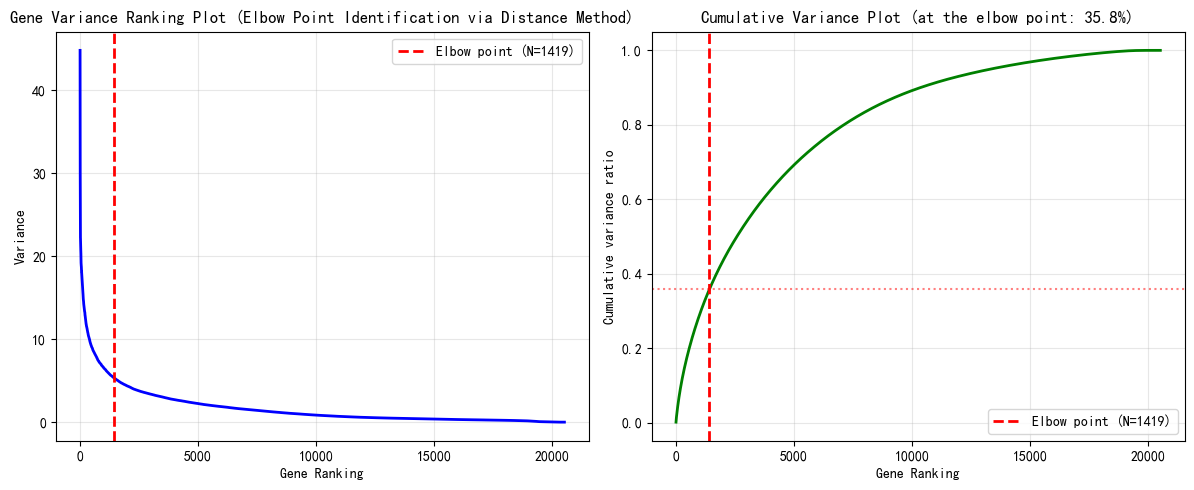

*Figure retained from the original homework run; not regenerated.*


## 4. Compare Ward clusters with tumor labels

Five clusters are specified because five tumor types are present. The saved run reported **ARI 0.993** and **NMI 0.991**; two LUAD samples joined the BRCA-dominated cluster. These are in-sample clustering measures, not classifier accuracy.


In [ ]:
print("\n4. Hierarchical Cluster Analysis...")
X_filtered = filtered_data.T.values
X_filtered_scaled = StandardScaler().fit_transform(X_filtered)

agg_clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')
cluster_labels = agg_clustering.fit_predict(X_filtered_scaled)

cluster_df = pd.DataFrame({
    'Sample': filtered_data.columns,
    'Cluster': cluster_labels,
    'True_Label': labels['Class'].values
})

ari = adjusted_rand_score(cluster_df['True_Label'], cluster_df['Cluster'])
nmi = normalized_mutual_info_score(cluster_df['True_Label'], cluster_df['Cluster'])

print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

confusion_mat = pd.crosstab(cluster_df['Cluster'], cluster_df['True_Label'])
print("\nConfusion Matrix Between Clustering and True Labels:")
print(confusion_mat)

cluster_purities = []
print("\nDetails of Each Cluster:")
for cluster_id in range(5):
    cluster_samples = cluster_df[cluster_df['Cluster'] == cluster_id]
    if len(cluster_samples) > 0:
        dominant_label = cluster_samples['True_Label'].mode()[0]
        dominant_count = cluster_samples['True_Label'].value_counts().iloc[0]
        purity = dominant_count / len(cluster_samples)
        cluster_purities.append(purity)
        print(f"cluster{cluster_id}: {len(cluster_samples)}samples, Main Types={dominant_label}, Purity={purity:.2f}")

sorted_indices = np.argsort(cluster_labels)

plt.figure(figsize=(20, 12))

heatmap_data = X_filtered_scaled.T[:100, sorted_indices]

grid_spec = plt.GridSpec(4, 1, height_ratios=[0.5, 0.5, 0.1, 8], hspace=0.05)

ax1 = plt.subplot(grid_spec[0])
true_labels = cluster_df.loc[sorted_indices, 'True_Label'].values
true_label_colors = [colors[label] for label in true_labels]

for i, (label, color) in enumerate(zip(true_labels, true_label_colors)):
    ax1.barh(0, 1, left=i, height=1, color=color, edgecolor='none')

ax1.set_xlim(0, len(true_labels))
ax1.set_ylim(0, 1)
ax1.set_yticks([0.5])
ax1.set_yticklabels(['True Label'])
ax1.set_xticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.set_title('Hierarchical Clustering Heatmap (k=5) - True Labels vs Clustering Results')

ax2 = plt.subplot(grid_spec[1])

cluster_colors = plt.cm.Set3(np.linspace(0, 1, 5))
for i, (cluster_id, color) in enumerate(zip(cluster_labels[sorted_indices], cluster_colors[cluster_labels[sorted_indices]])):
    ax2.barh(0, 1, left=i, height=1, color=color, edgecolor='none')

ax2.set_xlim(0, len(cluster_labels))
ax2.set_ylim(0, 1)
ax2.set_yticks([0.5])
ax2.set_yticklabels(['Cluster Label'])
ax2.set_xticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)


In [ ]:
ax3 = plt.subplot(grid_spec[2])

cluster_changes = np.where(np.diff(cluster_labels[sorted_indices]) != 0)[0] + 1
for change_point in cluster_changes:
    ax3.axvline(x=change_point, color='black', linewidth=1, alpha=0.5)
ax3.set_xlim(0, len(cluster_labels))
ax3.set_ylim(0, 1)
ax3.set_yticks([])
ax3.set_xticks([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax4 = plt.subplot(grid_spec[3])

im = ax4.imshow(heatmap_data, aspect='auto', cmap='viridis', 
                interpolation='nearest')
plt.colorbar(im, ax=ax4, label='Standardized Expression Level')

for change_point in cluster_changes:
    ax4.axvline(x=change_point-0.5, color='white', linewidth=2, alpha=0.8)

ax4.set_xlabel(f'Samples (sorted by cluster, total {filtered_data.shape[1]} samples)')
ax4.set_ylabel('Top 100 High-Variance Genes')
ax4.set_xticks([])  

from matplotlib.patches import Patch

true_legend_elements = [Patch(facecolor=color, label=label, edgecolor='black') 
                       for label, color in colors.items()]
true_legend = ax1.legend(handles=true_legend_elements, loc='upper left', 
                        bbox_to_anchor=(1.02, 1), borderaxespad=0., title="True Tumor Type")

cluster_legend_elements = [Patch(facecolor=cluster_colors[i], label=f'Cluster{i}', edgecolor='black') 
                          for i in range(5)]
cluster_legend = ax2.legend(handles=cluster_legend_elements, loc='upper left', 
                           bbox_to_anchor=(1.02, 1), borderaxespad=0., title="Clustering Results")

plt.tight_layout()
plt.show()

print("\nClustering Effect Evaluation:")
print("=" * 50)

for cluster_id in range(5):
    cluster_samples = cluster_df[cluster_df['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_samples)}Samples):")
    tumor_counts = cluster_samples['True_Label'].value_counts()
    for tumor_type, count in tumor_counts.items():
        percentage = count / len(cluster_samples) * 100
        print(f"  {tumor_type}: {count}Samples ({percentage:.1f}%)")

avg_purity = np.mean(cluster_purities) if cluster_purities else 0
print(f"Average Cluster Purity: {avg_purity:.3f}")


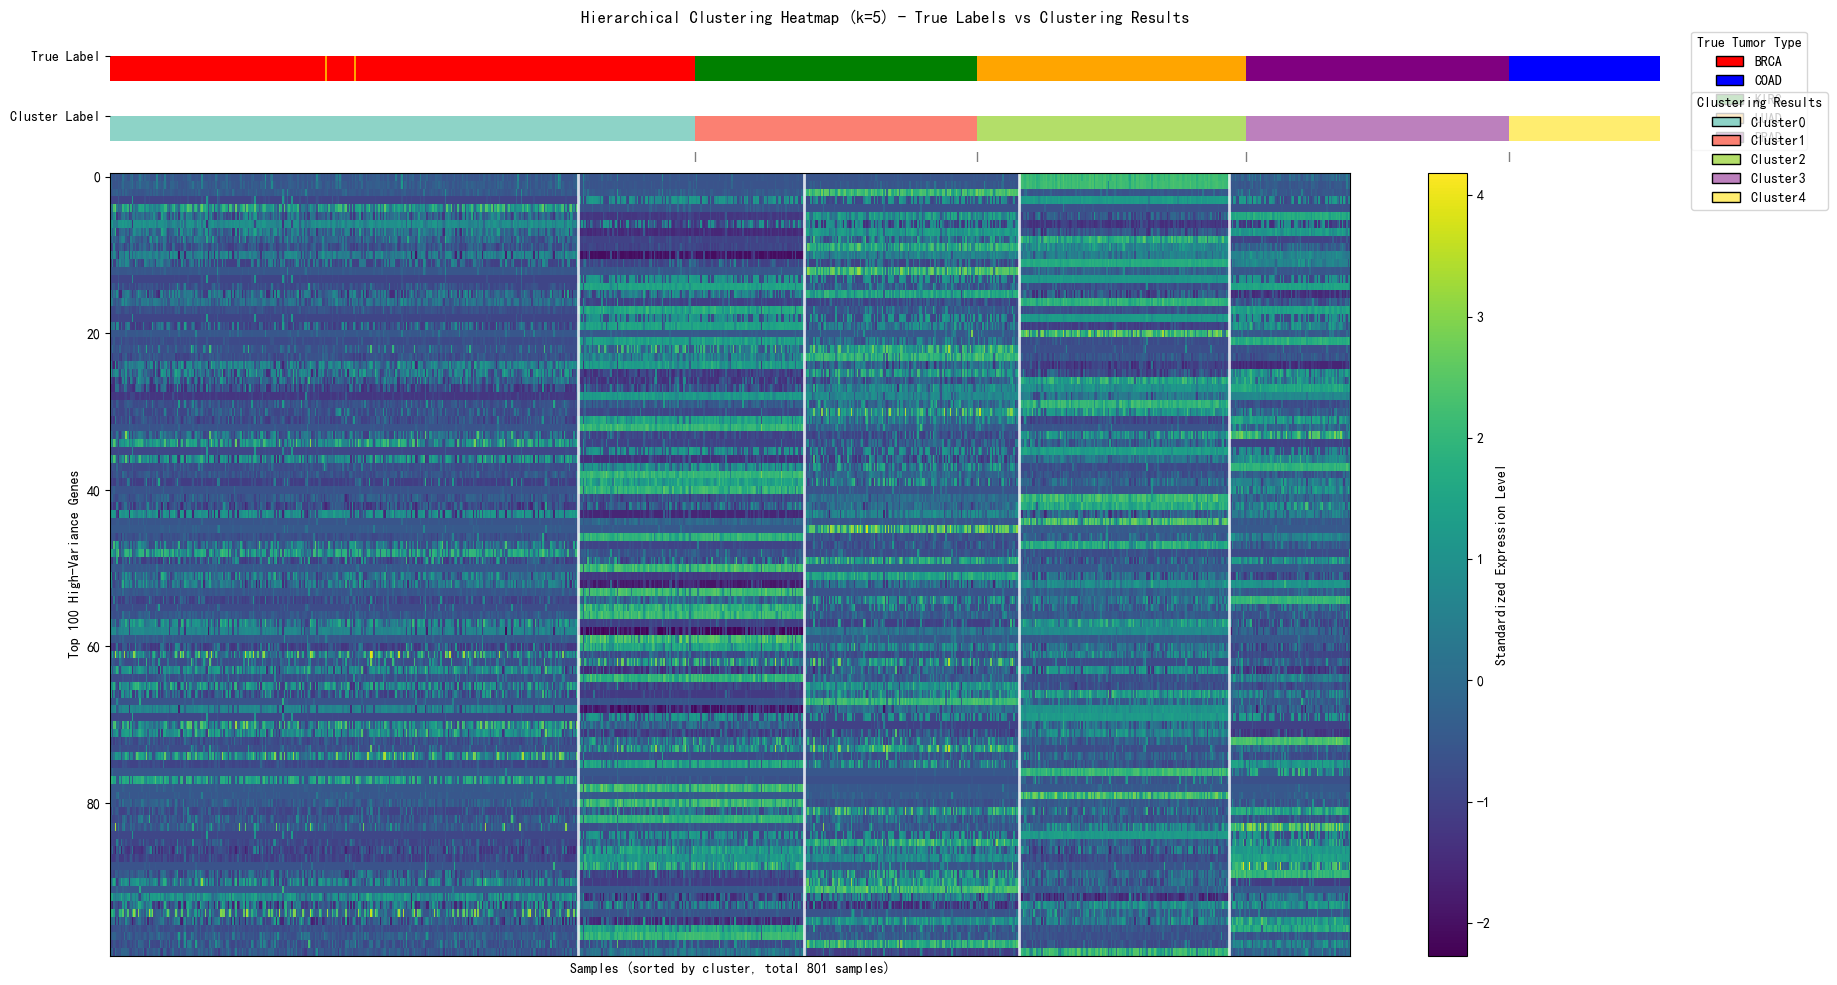

*Figure retained from the original homework run; not regenerated.*


## 5. Examine grouping within BRCA

The homework compares silhouette, Davies–Bouldin, a K-means inertia elbow, a simplified maximum-gap score and resampling stability. Suggested k values were **2, 2, 5, 10 and 2**. The original weighted average selected **k = 5**. That choice is retained as a heuristic, not evidence of five validated molecular subtypes.


In [ ]:
import os
os.environ['OMP_NUM_THREADS'] = '2'

print("\n5. BRCA Subclustering Analysis - Using Ensemble Clustering...")
brca_indices = labels[labels['Class'] == 'BRCA'].index
brca_data = filtered_data[brca_indices]

print(f"Number of BRCA samples: {brca_data.shape[1]}")

X_brca = brca_data.T.values
X_brca_scaled = StandardScaler().fit_transform(X_brca)

print("\nMethod 1: Silhouette Score")
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels_k = clustering.fit_predict(X_brca_scaled)
    if len(np.unique(cluster_labels_k)) > 1:
        score = silhouette_score(X_brca_scaled, cluster_labels_k)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Suggested number of clusters by Silhouette Score: {optimal_k_silhouette}")

print("\nMethod 2: Davies-Bouldin Index")
from sklearn.metrics import davies_bouldin_score

db_scores = []
for k in k_range:
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels_k = clustering.fit_predict(X_brca_scaled)
    if len(np.unique(cluster_labels_k)) > 1:
        score = davies_bouldin_score(X_brca_scaled, cluster_labels_k)
        db_scores.append(score)
    else:
        db_scores.append(np.inf)

optimal_k_db = k_range[np.argmin(db_scores)]
print(f"Suggested number of clusters by Davies-Bouldin Index: {optimal_k_db}")

print("\nMethod 3: Elbow Method (based on inertia)")
from sklearn.cluster import KMeans

inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_brca_scaled)
    inertias.append(kmeans.inertia_)

def find_inertia_elbow(inertias):
    """Find the elbow point using distance method"""
    n = len(inertias)
    x = np.arange(2, n+2)
    y = np.array(inertias)

    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    distances = []
    for i in range(n):
        p = np.array([x[i], y[i]])
        d = np.abs(((p2-p1)[0] * (p1-p)[1] - (p2-p1)[1] * (p1-p)[0])) / np.linalg.norm(p2-p1)
        distances.append(d)
    
    elbow_idx = np.argmax(distances)
    return elbow_idx + 2

optimal_k_elbow = find_inertia_elbow(inertias)
print(f"Suggested number of clusters by Elbow Method: {optimal_k_elbow}")


In [ ]:
print("\nMethod 4: Gap Statistic")
from sklearn.utils import resample

def calculate_gap_statistic(X, k_max=10, n_bootstrap=10):
    """Calculate Gap Statistic"""
    gaps = []
    for k in k_range:

        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        Wk = np.log(kmeans.inertia_)

        reference_inertias = []
        min_vals = X.min(axis=0)
        max_vals = X.max(axis=0)
        
        for _ in range(n_bootstrap):

            reference_data = np.random.uniform(min_vals, max_vals, size=X.shape)
            kmeans_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_ref.fit(reference_data)
            reference_inertias.append(np.log(kmeans_ref.inertia_))

        gap = np.mean(reference_inertias) - Wk
        gaps.append(gap)

    optimal_k_gap = k_range[np.argmax(gaps)]
    return optimal_k_gap, gaps

optimal_k_gap, gap_scores = calculate_gap_statistic(X_brca_scaled)
print(f"Suggested number of clusters by Gap Statistic: {optimal_k_gap}")

print("\nMethod 5: Consensus Clustering")
def consensus_clustering(X, max_k=10, n_iterations=20):
    """Simplified consensus clustering method"""
    consensus_scores = []
    
    for k in k_range:

        cluster_assignments = []
        
        for _ in range(n_iterations):

            n_samples = X.shape[0]
            sample_indices = np.random.choice(n_samples, size=int(0.8*n_samples), replace=False)
            X_sampled = X[sample_indices]

            clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
            labels = clustering.fit_predict(X_sampled)

            indicator_matrix = np.zeros((len(sample_indices), len(sample_indices)))
            for i in range(len(labels)):
                for j in range(len(labels)):
                    if labels[i] == labels[j]:
                        indicator_matrix[i, j] = 1
            
            cluster_assignments.append((sample_indices, indicator_matrix))

        n_total = X.shape[0]
        consensus_matrix = np.zeros((n_total, n_total))
        count_matrix = np.zeros((n_total, n_total))
        
        for sample_indices, indicator in cluster_assignments:
            for idx_i, i in enumerate(sample_indices):
                for idx_j, j in enumerate(sample_indices):
                    consensus_matrix[i, j] += indicator[idx_i, idx_j]
                    count_matrix[i, j] += 1

        count_matrix[count_matrix == 0] = 1
        consensus_matrix = consensus_matrix / count_matrix

        consensus_score = np.mean((consensus_matrix < 0.1) | (consensus_matrix > 0.9))
        consensus_scores.append(consensus_score)
    
    optimal_k_consensus = k_range[np.argmax(consensus_scores)]
    return optimal_k_consensus, consensus_scores


In [ ]:
optimal_k_consensus, consensus_scores = consensus_clustering(X_brca_scaled)
print(f"Suggested number of clusters by Consensus Clustering: {optimal_k_consensus}")

print("\n" + "="*50)
print("Ensemble Clustering Results Summary:")
print(f"1. Silhouette Score: {optimal_k_silhouette}")
print(f"2. Davies-Bouldin Index: {optimal_k_db}")
print(f"3. Elbow Method: {optimal_k_elbow}")
print(f"4. Gap Statistic: {optimal_k_gap}")
print(f"5. Consensus Clustering: {optimal_k_consensus}")

methods_results = [optimal_k_silhouette, optimal_k_db, optimal_k_elbow, optimal_k_gap, optimal_k_consensus]
optimal_k_vote = np.bincount(methods_results).argmax()
print(f"\nVoting result suggested number of clusters: {optimal_k_vote}")

weights = [0.3, 0.1, 0.2, 0.3, 0.1]
# Retain the homework heuristic; this average does not validate a subtype count.
weighted_k = int(np.round(np.average(methods_results, weights=weights)))
print(f"Weighted average suggested number of clusters: {weighted_k}")

optimal_k_final = weighted_k
print(f"\nFinal selected number of clusters: {optimal_k_final}")

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title(f'Silhouette Score Method (Optimal k={optimal_k_silhouette})')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(k_range, db_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=optimal_k_db, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.title(f'Davies-Bouldin Index Method (Optimal k={optimal_k_db})')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title(f'Elbow Method (Optimal k={optimal_k_elbow})')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
plt.plot(k_range, gap_scores, 'co-', linewidth=2, markersize=8)
plt.axvline(x=optimal_k_gap, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title(f'Gap Statistic Method (Optimal k={optimal_k_gap})')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(k_range, consensus_scores, 'mo-', linewidth=2, markersize=8)
plt.axvline(x=optimal_k_consensus, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Consensus Score')
plt.title(f'Consensus Clustering Method (Optimal k={optimal_k_consensus})')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
methods_names = ['Silhouette', 'DB Index', 'Elbow', 'Gap Statistic', 'Consensus']
methods_values = methods_results
colors = ['blue', 'green', 'red', 'cyan', 'magenta']

bars = plt.bar(methods_names, methods_values, color=colors, alpha=0.7)
plt.axhline(y=optimal_k_vote, color='black', linestyle='--', label=f'Vote: k={optimal_k_vote}')
plt.axhline(y=weighted_k, color='red', linestyle='--', label=f'Weighted: k={weighted_k}')
plt.ylabel('Suggested k value')


In [ ]:
plt.title('Optimal k Suggested by Each Method')
plt.legend()
for bar, value in zip(bars, methods_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nPerforming hierarchical clustering with optimal k={optimal_k_final}...")
final_clustering = AgglomerativeClustering(n_clusters=optimal_k_final, linkage='ward')
brca_clusters = final_clustering.fit_predict(X_brca_scaled)

unique_clusters, cluster_counts = np.unique(brca_clusters, return_counts=True)
print(f"\nBRCA Samples Subcluster Distribution:")
for cluster_id, count in zip(unique_clusters, cluster_counts):
    print(f"  Subcluster {cluster_id}: {count} samples ({count/len(brca_clusters)*100:.1f}%)")

print("\nPlotting BRCA Subclustering Heatmap...")

sorted_indices_brca = np.argsort(brca_clusters)

plt.figure(figsize=(18, 12))

heatmap_data_brca = X_brca_scaled.T[:50, sorted_indices_brca]

grid_spec = plt.GridSpec(3, 1, height_ratios=[0.5, 0.1, 8], hspace=0.05)

ax1 = plt.subplot(grid_spec[0])

brca_cluster_colors = plt.cm.tab10(np.linspace(0, 1, optimal_k_final))
for i, (cluster_id, color) in enumerate(zip(brca_clusters[sorted_indices_brca], 
                                           brca_cluster_colors[brca_clusters[sorted_indices_brca]])):
    ax1.barh(0, 1, left=i, height=1, color=color, edgecolor='none')

ax1.set_xlim(0, len(brca_clusters))
ax1.set_ylim(0, 1)
ax1.set_yticks([0.5])
ax1.set_yticklabels(['BRCA Subcluster'])
ax1.set_xticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.set_title(f'BRCA Sample Subclustering Heatmap (k={optimal_k_final}, determined by ensemble clustering)')

ax2 = plt.subplot(grid_spec[1])

cluster_changes_brca = np.where(np.diff(brca_clusters[sorted_indices_brca]) != 0)[0] + 1
for change_point in cluster_changes_brca:
    ax2.axvline(x=change_point, color='black', linewidth=1, alpha=0.5)
ax2.set_xlim(0, len(brca_clusters))
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax3 = plt.subplot(grid_spec[2])

im = ax3.imshow(heatmap_data_brca, aspect='auto', cmap='RdBu_r', 
                interpolation='nearest', vmin=-3, vmax=3)
plt.colorbar(im, ax=ax3, label='Standardized Expression')

for change_point in cluster_changes_brca:
    ax3.axvline(x=change_point-0.5, color='white', linewidth=2, alpha=0.8)

ax3.set_xlabel(f'BRCA Samples (sorted by subcluster, total {len(brca_clusters)} samples)')
ax3.set_ylabel('Top 50 High-Variance Genes')
ax3.set_xticks([])

from matplotlib.patches import Patch


In [ ]:
brca_legend_elements = [Patch(facecolor=brca_cluster_colors[i], label=f'Subcluster {i}', edgecolor='black') 
                       for i in range(optimal_k_final)]
brca_legend = ax1.legend(handles=brca_legend_elements, loc='upper left', 
                        bbox_to_anchor=(1.02, 1), borderaxespad=0., title="BRCA Subclusters")

plt.tight_layout()
plt.show()


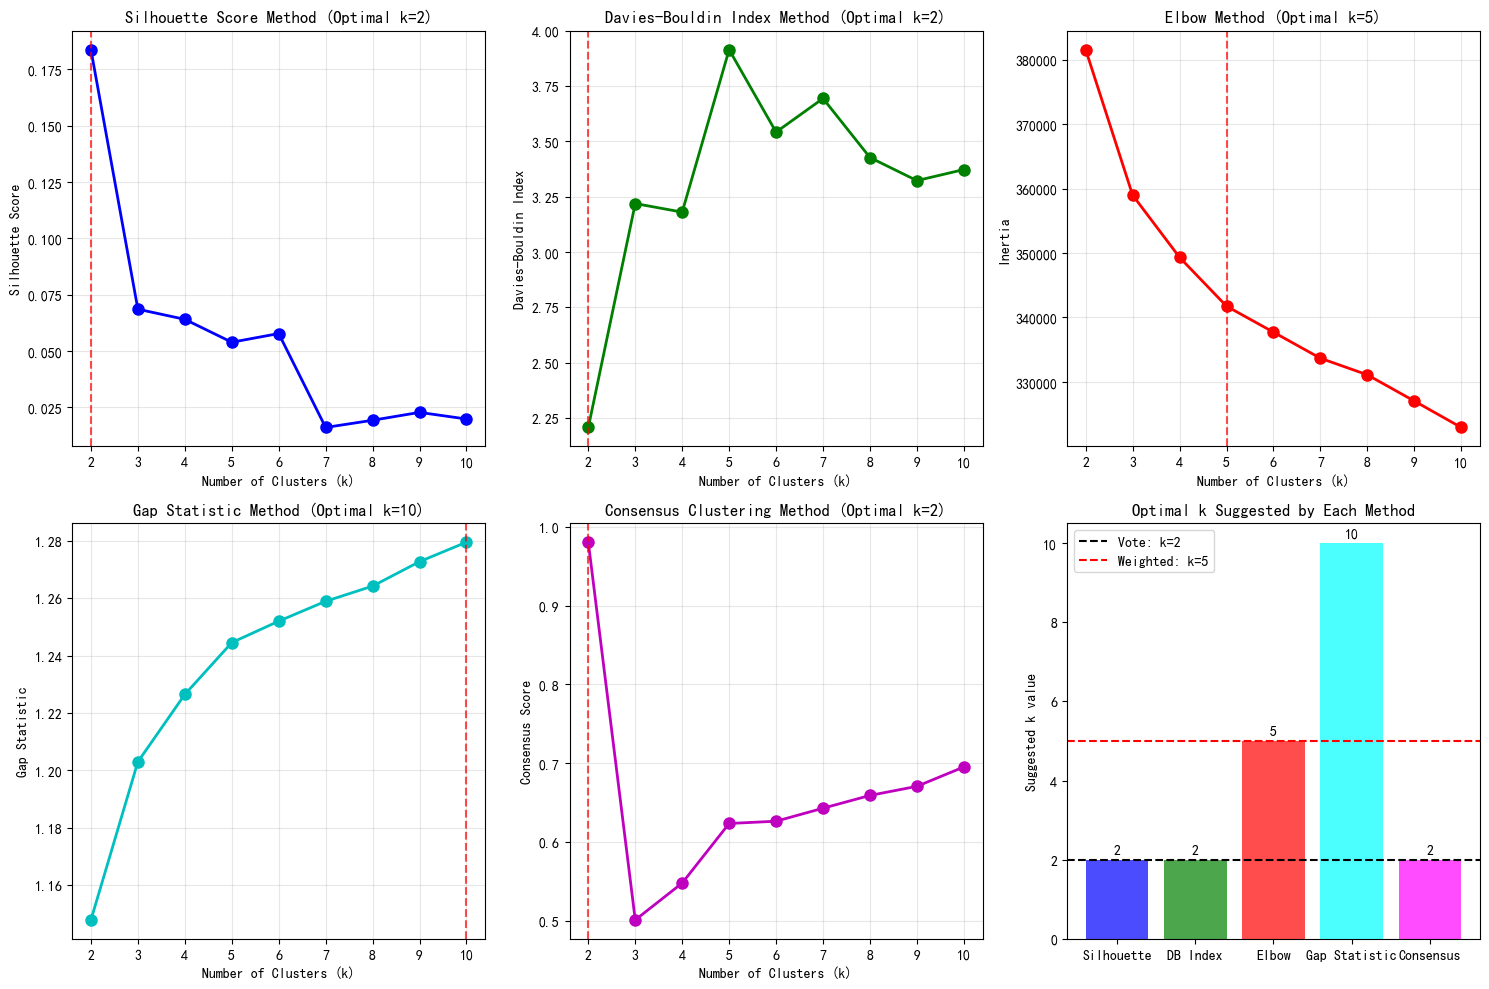

*Figure retained from the original homework run; not regenerated.*


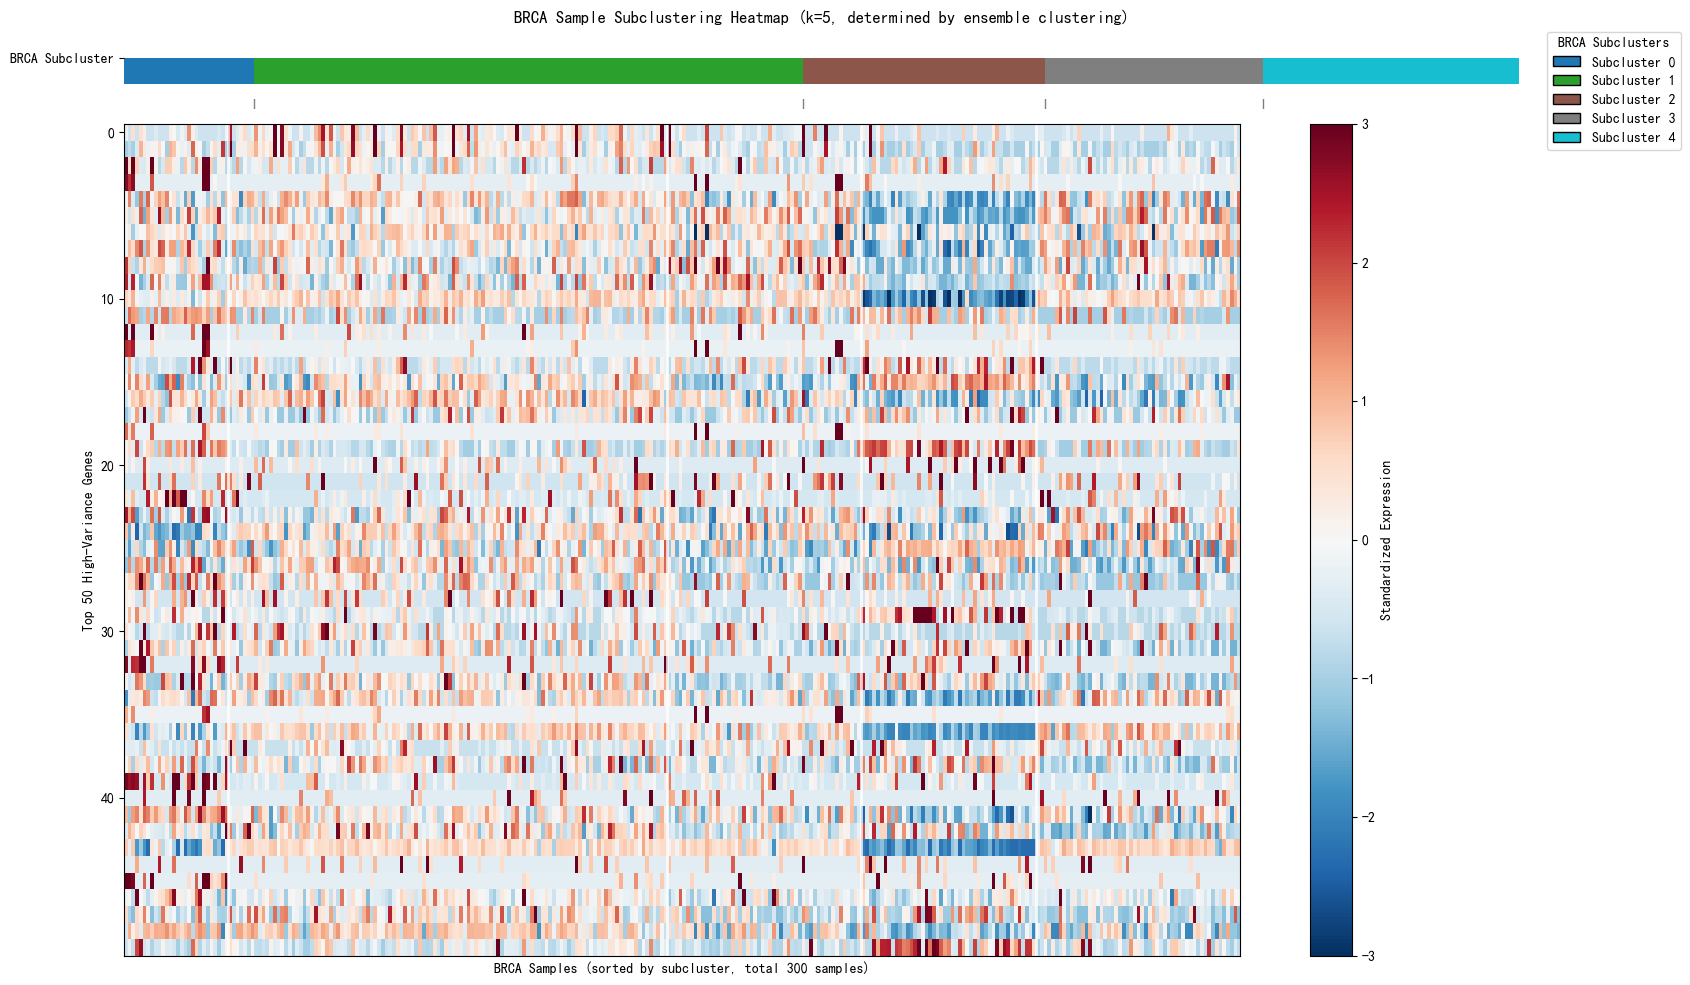

*Figure retained from the original homework run; not regenerated.*


## 6. Inspect cluster-associated expression patterns

The original one-versus-rest Welch tests, BH correction and median-ratio filtering are retained. The code also compares gene sets and summarizes variation in cluster medians. Because the same data defined the clusters, these are post-clustering exploratory comparisons. The expression transformation is not specified in the assignment; the computed median ratios should not be interpreted as validated biological fold changes.


In [ ]:
print("\n6. Differential Gene Expression Analysis: Finding Unique and Common Genes")
print("=" * 60)

from statsmodels.stats.multitest import multipletests

brca_cluster_genes = []
brca_cluster_upregulated = []
brca_cluster_downregulated = []

try:
    k_value = optimal_k_final
except NameError:
    try:
        k_value = optimal_k_vote
    except NameError:
        try:
            k_value = optimal_k
        except NameError:
            k_value = optimal_k_silhouette

print(f"Using k={k_value} for BRCA subcluster differential gene analysis")

cluster_medians = []
for cluster_id in range(k_value):
    cluster_samples = brca_indices[brca_clusters == cluster_id]
    cluster_medians.append(brca_data[cluster_samples].median(axis=1))

for cluster_id in range(k_value):
    print(f"\nAnalyzing subcluster {cluster_id} (contains {np.sum(brca_clusters == cluster_id)} samples)...")

    cluster_samples = brca_indices[brca_clusters == cluster_id]

    other_samples = brca_indices[brca_clusters != cluster_id]

    if len(cluster_samples) < 2 or len(other_samples) < 2:
        print(f"  Warning: Subcluster {cluster_id} has insufficient samples, skipping analysis")
        brca_cluster_genes.append(set())
        brca_cluster_upregulated.append(set())
        brca_cluster_downregulated.append(set())
        continue

    p_values = []
    fold_changes = []
    
    for gene in brca_data.index:
        cluster_exp = brca_data.loc[gene, cluster_samples]
        other_exp = brca_data.loc[gene, other_samples]

        t_stat, p_val = stats.ttest_ind(cluster_exp, other_exp, equal_var=False)
        p_values.append(p_val)

        cluster_median = np.median(cluster_exp)
        other_median = np.median(other_exp)
        if other_median > 0 and cluster_median > 0:
            fc = cluster_median / other_median
            log2_fc = np.log2(fc)
        elif cluster_median > 0 and other_median == 0:
            log2_fc = 10
        elif cluster_median == 0 and other_median > 0:
            log2_fc = -10
        else:
            log2_fc = 0
        fold_changes.append(log2_fc)

    reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')

    sig_indices = np.where(reject)[0]
    sig_genes = brca_data.index[sig_indices].tolist()

    sig_genes_filtered = []
    up_genes = []
    down_genes = []
    
    for idx in sig_indices:
        gene = brca_data.index[idx]
        log2_fc = fold_changes[idx]
        if abs(log2_fc) > 1:
            sig_genes_filtered.append(gene)
            if log2_fc > 1:
                up_genes.append((gene, log2_fc))
            else:
                down_genes.append((gene, log2_fc))

    up_genes.sort(key=lambda x: x[1], reverse=True)
    down_genes.sort(key=lambda x: x[1])
    
    print(f"  Total significantly differential genes (FDR<0.05): {len(sig_genes)}")
    print(f"  Genes with >2-fold change: {len(sig_genes_filtered)}")
    print(f"    - Upregulated genes (log2FC > 1): {len(up_genes)}")
    print(f"    - Downregulated genes (log2FC < -1): {len(down_genes)}")

    brca_cluster_genes.append(set(sig_genes_filtered))
    brca_cluster_upregulated.append(set([gene for gene, _ in up_genes]))
    brca_cluster_downregulated.append(set([gene for gene, _ in down_genes]))


In [ ]:
print("\n" + "=" * 60)
print("Gene Intersection Analysis:")
print("=" * 60)

unique_genes_per_cluster = []
unique_up_genes_per_cluster = []
unique_down_genes_per_cluster = []

for i in range(k_value):

    other_clusters_all = set().union(*[brca_cluster_genes[j] for j in range(k_value) if j != i])
    unique_genes = brca_cluster_genes[i] - other_clusters_all
    unique_genes_per_cluster.append(unique_genes)

    other_clusters_up = set().union(*[brca_cluster_upregulated[j] for j in range(k_value) if j != i])
    unique_up_genes = brca_cluster_upregulated[i] - other_clusters_up
    unique_up_genes_per_cluster.append(unique_up_genes)

    other_clusters_down = set().union(*[brca_cluster_downregulated[j] for j in range(k_value) if j != i])
    unique_down_genes = brca_cluster_downregulated[i] - other_clusters_down
    unique_down_genes_per_cluster.append(unique_down_genes)
    
    print(f"\nSubcluster {i}:")
    print(f"  Total unique genes: {len(unique_genes)}")
    print(f"  - Unique upregulated genes: {len(unique_up_genes)}")
    print(f"  - Unique downregulated genes: {len(unique_down_genes)}")

print("\n" + "=" * 60)
print("Common Genes Analysis:")
print("=" * 60)

if k_value > 0 and all(len(gene_set) > 0 for gene_set in brca_cluster_genes):
    common_diff_genes = set.intersection(*brca_cluster_genes)
else:
    common_diff_genes = set()
print(f"Number of genes significantly differential in all subclusters: {len(common_diff_genes)}")

print("\nFinding genes stably expressed across all subclusters...")
stable_genes = []

for gene in brca_data.index:

    expr_values = []
    for cluster_id in range(k_value):
        cluster_samples = brca_indices[brca_clusters == cluster_id]
        if len(cluster_samples) > 0:
            median_expr = brca_data.loc[gene, cluster_samples].median()
            expr_values.append(median_expr)
        else:
            expr_values.append(0)

    if np.mean(expr_values) > 0:
        cv = np.std(expr_values) / np.mean(expr_values)

        if cv < 0.2 and np.mean(expr_values) > 1:
            stable_genes.append((gene, cv, np.mean(expr_values)))

stable_genes.sort(key=lambda x: x[2], reverse=True)

print(f"Number of stably expressed genes (CV<0.2): {len(stable_genes)}")

print("\n" + "=" * 60)
print("Results Presentation:")
print("=" * 60)

if len(common_diff_genes) > 0:
    print(f"\n1. Genes significantly differential in all subclusters (top 20):")
    for i, gene in enumerate(list(common_diff_genes)[:20]):

        gene_short = gene.split('|')[0] if '|' in gene else gene[:15]
        print(f"   {i+1:2d}. {gene_short} (Full ID: {gene})")
else:
    print("\n1. No genes are significantly differential in all subclusters")


In [ ]:
if len(stable_genes) > 0:
    print(f"\n2. Genes stably expressed across all subclusters (top 20, sorted by expression level):")
    for i, (gene, cv, mean_expr) in enumerate(stable_genes[:20]):

        gene_short = gene.split('|')[0] if '|' in gene else gene[:15]
        print(f"   {i+1:2d}. {gene_short:20s} Average expression: {mean_expr:.2f}, CV: {cv:.3f} (Full ID: {gene})")

print("\n3. Unique genes for each subcluster:")
for i in range(k_value):
    print(f"\n   Unique genes of subcluster {i}:")

    if len(unique_up_genes_per_cluster[i]) > 0:
        print(f"     Unique upregulated genes (top 10):")
        for j, gene in enumerate(list(unique_up_genes_per_cluster[i])[:10]):
            gene_short = gene.split('|')[0] if '|' in gene else gene[:15]
            print(f"       {j+1:2d}. {gene_short} (Full ID: {gene})")
    else:
        print(f"     No unique upregulated genes")

    if len(unique_down_genes_per_cluster[i]) > 0:
        print(f"     Unique downregulated genes (top 10):")
        for j, gene in enumerate(list(unique_down_genes_per_cluster[i])[:10]):
            gene_short = gene.split('|')[0] if '|' in gene else gene[:15]
            print(f"       {j+1:2d}. {gene_short} (Full ID: {gene})")
    else:
        print(f"     No unique downregulated genes")

print("\n" + "=" * 60)
print("Visualizing Gene Expression Patterns:")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Analysis of Unique and Common Genes in BRCA Subclusters (k={k_value})', fontsize=16)

ax1 = axes[0, 0]
unique_counts = [len(unique_genes_per_cluster[i]) for i in range(k_value)]
up_counts = [len(unique_up_genes_per_cluster[i]) for i in range(k_value)]
down_counts = [len(unique_down_genes_per_cluster[i]) for i in range(k_value)]

x = np.arange(k_value)
width = 0.25

ax1.bar(x - width, unique_counts, width, label='Total unique genes', color='lightblue')
ax1.bar(x, up_counts, width, label='Unique upregulated genes', color='lightcoral')
ax1.bar(x + width, down_counts, width, label='Unique downregulated genes', color='lightgreen')

ax1.set_xlabel('Subcluster')
ax1.set_ylabel('Gene Count')
ax1.set_title('Number of Unique Genes per Subcluster')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Subcluster{i}' for i in range(k_value)])
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]

top_unique_genes = []
for i in range(k_value):
    top_genes = list(unique_up_genes_per_cluster[i])[:5]
    top_unique_genes.extend(top_genes)

if len(top_unique_genes) > 0:

    heatmap_data = []
    for gene in top_unique_genes[:20]:
        expr_row = []
        for cluster_id in range(k_value):
            cluster_samples = brca_indices[brca_clusters == cluster_id]
            median_expr = brca_data.loc[gene, cluster_samples].median()
            expr_row.append(median_expr)
        heatmap_data.append(expr_row)
    
    heatmap_data = np.array(heatmap_data)

    heatmap_data_norm = (heatmap_data - heatmap_data.min(axis=1, keepdims=True)) / \
                       (heatmap_data.max(axis=1, keepdims=True) - heatmap_data.min(axis=1, keepdims=True) + 1e-10)
    
    im = ax2.imshow(heatmap_data_norm, aspect='auto', cmap='viridis')
    ax2.set_xlabel('Subcluster')
    ax2.set_ylabel('Unique Upregulated Genes')
    ax2.set_title('Expression Patterns of Unique Upregulated Genes Across Subclusters')
    ax2.set_xticks(range(k_value))
    ax2.set_xticklabels([f'Subcluster{i}' for i in range(k_value)])
    ax2.set_yticks(range(len(top_unique_genes[:20])))
    ax2.set_yticklabels([gene.split('|')[0] if '|' in gene else gene[:10] for gene in top_unique_genes[:20]])
    plt.colorbar(im, ax=ax2, label='Normalized Expression')
else:
    ax2.text(0.5, 0.5, 'Not enough unique upregulated genes', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Unique Upregulated Gene Expression Patterns')


In [ ]:
ax3 = axes[1, 0]
if len(stable_genes) > 0:

    top_stable_genes = [gene for gene, _, _ in stable_genes[:10]]

    heatmap_data_stable = []
    for gene in top_stable_genes:
        expr_row = []
        for cluster_id in range(k_value):
            cluster_samples = brca_indices[brca_clusters == cluster_id]
            median_expr = brca_data.loc[gene, cluster_samples].median()
            expr_row.append(median_expr)
        heatmap_data_stable.append(expr_row)
    
    heatmap_data_stable = np.array(heatmap_data_stable)
    
    im3 = ax3.imshow(heatmap_data_stable, aspect='auto', cmap='YlOrRd')
    ax3.set_xlabel('Subcluster')
    ax3.set_ylabel('Stably Expressed Genes')
    ax3.set_title('Expression Levels of Stably Expressed Genes Across Subclusters')
    ax3.set_xticks(range(k_value))
    ax3.set_xticklabels([f'Subcluster{i}' for i in range(k_value)])
    ax3.set_yticks(range(len(top_stable_genes)))
    ax3.set_yticklabels([gene.split('|')[0] if '|' in gene else gene[:10] for gene in top_stable_genes])
    plt.colorbar(im3, ax=ax3, label='Expression Level')
else:
    ax3.text(0.5, 0.5, 'Not enough stably expressed genes', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Stably Expressed Gene Expression Patterns')

ax4 = axes[1, 1]
overlap_matrix = np.zeros((k_value, k_value))
for i in range(k_value):
    for j in range(k_value):
        if i != j:
            overlap = len(brca_cluster_genes[i] & brca_cluster_genes[j])
            overlap_matrix[i, j] = overlap
    
im4 = ax4.imshow(overlap_matrix, cmap='Blues')
ax4.set_xlabel('Subcluster')
ax4.set_ylabel('Subcluster')
ax4.set_title('Number of Overlapping Differential Genes Between Subclusters')
ax4.set_xticks(range(k_value))
ax4.set_xticklabels([f'Subcluster{i}' for i in range(k_value)])
ax4.set_yticks(range(k_value))
ax4.set_yticklabels([f'Subcluster{i}' for i in range(k_value)])

for i in range(k_value):
    for j in range(k_value):
        if i != j:
            ax4.text(j, i, f'{int(overlap_matrix[i, j])}', 
                    ha='center', va='center', color='white' if overlap_matrix[i, j] > np.max(overlap_matrix)/2 else 'black')
    
plt.colorbar(im4, ax=ax4, label='Number of Overlapping Genes')

plt.tight_layout()
plt.show()


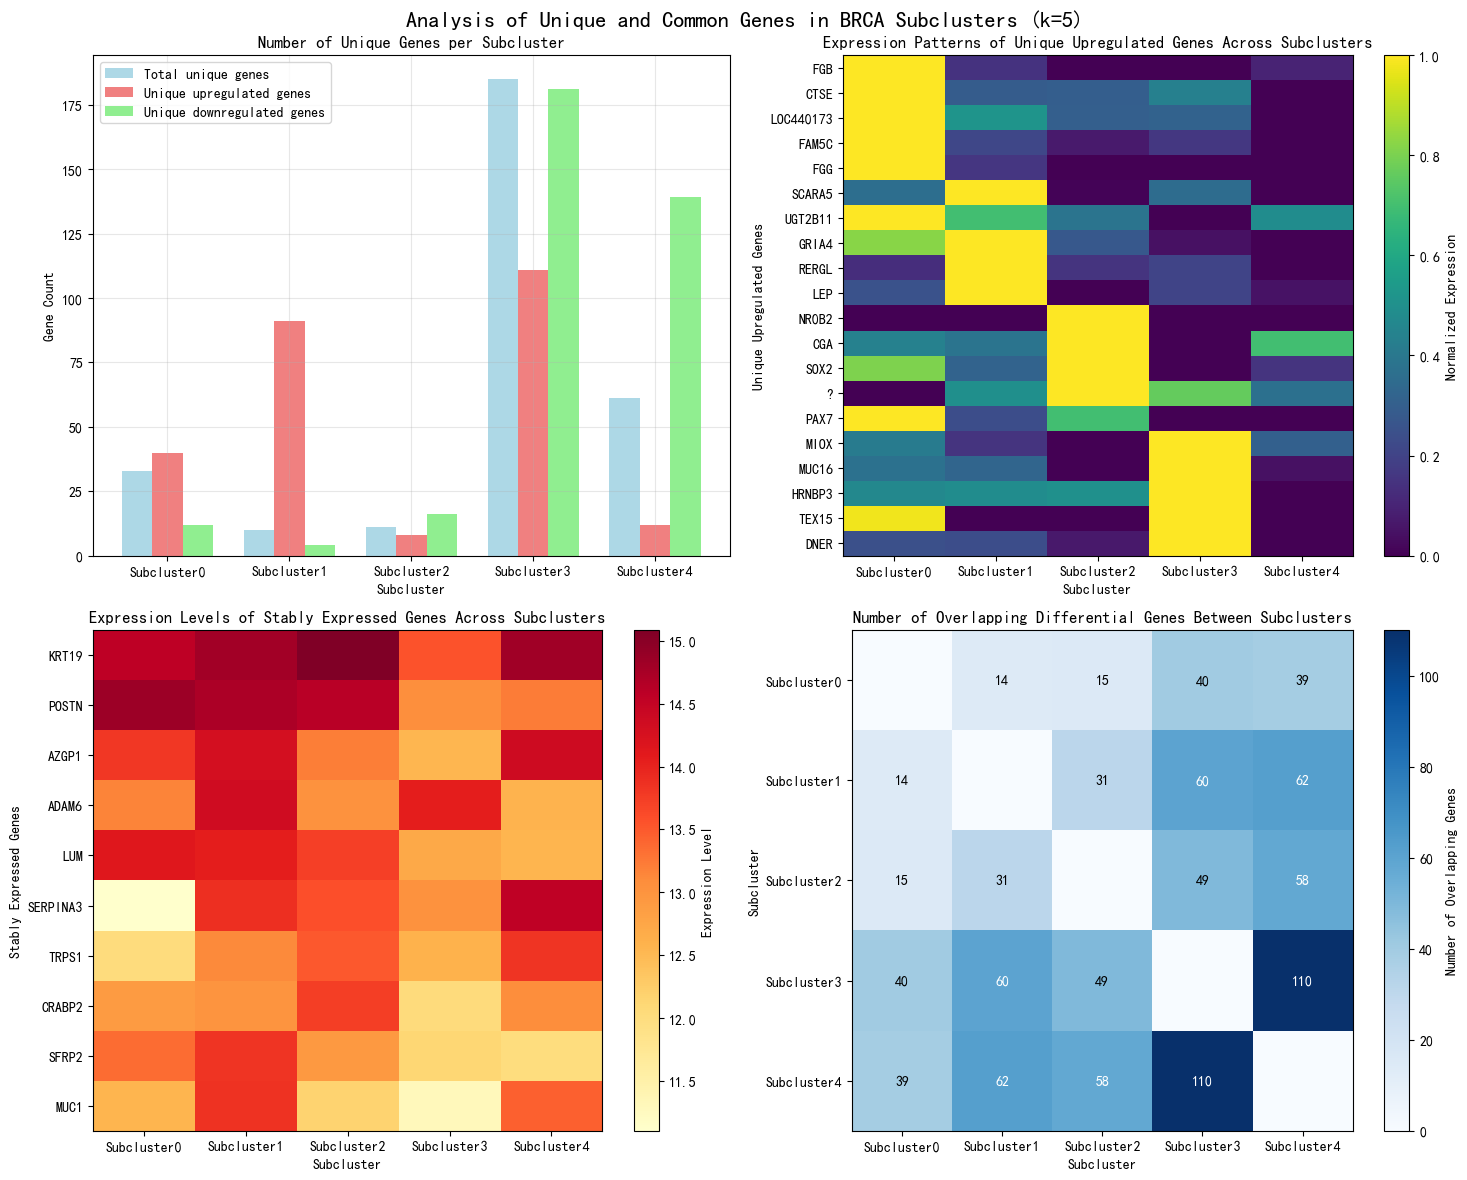

*Figure retained from the original homework run; not regenerated.*


## 7. Interpretation

The five-cluster partition agrees closely with the supplied tumor labels. Within
BRCA, disagreement among diagnostics makes the subgroup structure less definitive.
The weighted k and the original stability score are heuristic choices: the latter
includes diagonal and unobserved sample pairs, which can inflate apparent stability.

SOX2 appears in the original cluster-associated gene output. Its position in the
printed list is not an importance rank because that list was constructed from a set.
The homework's drug discussion is omitted here; these analyses do not establish
therapeutic targets or treatment effects.

The next notebook uses supplied PAM50 labels for a supervised question. The clusters
here are not substitutes for those labels.

[Original saved text output](../results/pan_cancer/original_stdout.txt) ·
[Editorial notes](../docs/editorial_notes.md)
